# 16 · Final manuscript consistency and compilation audit — Gate 17

**Purpose.** Audit the frozen evidence package after Gate 16 without re-estimating any model.

This notebook verifies:

- passed dependencies from Gates 14–16;
- numerical agreement between frozen CSV outputs, manuscript, and supplement;
- abstract length and absence of numerical detail;
- figure, citation, label, and reference completeness;
- clean LaTeX compilation of the manuscript and supplementary material;
- remaining author-dependent submission decisions separately from computational validity.

Because opening a private GitHub notebook in Colab does not clone its repository, the notebook first restores an integrity-checked editorial snapshot containing the manuscript, supplement, bibliography, tables, and figures used by this audit. Gate 17 may pass while the submission-readiness section still records unresolved authorship, funding, repository DOI, or final-title decisions.


In [6]:
%pip -q install pypdf pymupdf


In [7]:
from pathlib import Path
import base64, hashlib, json

ROOT = Path("/content/colombia-stochastic-access")
SNAPSHOT = json.loads("{\"paper/manuscript.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\documentclass[11pt]{article}\\n\\\\usepackage[margin=1in]{geometry}\\n\\\\usepackage{amsmath,amssymb,booktabs,graphicx,microtype}\\n\\\\usepackage{setspace,lineno,natbib,hyperref}\\n\\\\hypersetup{hidelinks}\\n\\\\usepackage[T1]{fontenc}\\n\\\\usepackage{lmodern}\\n\\\\usepackage[utf8]{inputenc}\\n\\\\doublespacing\\n\\\\linenumbers\\n\\n\\\\title{Metropolitan scope amplifies measured gender disparities in stochastic urban accessibility: Evidence from Bogotá's 2023 mobility survey}\\n\\\\author{Andy Rafael Domínguez-Monterroza\\\\\\\\\\nDepartment of Mathematics, Pontificia Universidad Javeriana, Bogotá, Colombia\\\\\\\\\\nCorresponding author: \\\\texttt{andy\\\\_dominguez01@javeriana.edu.co}}\\n\\\\date{}\\n\\n\\\\begin{document}\\n\\\\maketitle\\n\\n\\\\begin{abstract}\\nUrban accessibility estimates are commonly conditioned on administrative boundaries, potentially concealing inequalities generated by cross-border mobility. We introduce a stochastic accessibility framework based on first-passage times in an origin--destination Markov network and apply it to Bogotá's regional household mobility survey. Weighted trips define population and sex-specific transition kernels to employment, education, and health destinations. A symmetric decomposition separates residential-distribution and mobility-kernel components, while shared household-cluster bootstrap perturbations propagate uncertainty across nested territorial scopes. Female--male accessibility gaps are larger in the complete metropolitan network than within Bogotá D.C., and the estimated gaps increase on average as progressively broader functional interactions are incorporated. This response remains supported after simultaneous inference for all destination purposes, although the intermediate scopes do not form a strictly monotone sequence in every case. Metropolitan amplification is concentrated in transition dynamics rather than residential composition. The results show that territorial scope is part of the measured inequality estimand rather than a neutral preprocessing choice. The framework is descriptive and does not identify causal effects of municipal boundaries.\\n\\\\end{abstract}\\n\\n\\\\noindent\\\\textbf{Keywords:} stochastic accessibility; first-passage time; human mobility; gender inequality; metropolitan networks; Bogotá\\n\\n\\\\section{Introduction}\\nAccessibility links transport systems to the opportunities that people can reach and is therefore central to transport equity \\\\citep{hansen1959,pereira2017}. Standard place-based indicators commonly combine a fixed travel cost with a cumulative or gravity-based opportunity function. These measures are useful for planning, but they usually treat connectivity as deterministic and take the study boundary as given. In metropolitan systems, however, observed mobility repeatedly crosses administrative borders. An estimate restricted to the central municipality can therefore answer a materially different question from an estimate based on the functional urban region.\\n\\nGender is a particularly relevant dimension of this boundary problem. Large-scale mobility studies have documented systematic gender differences in travel diversity, trip purpose, mode use, and exposure to urban infrastructure \\\\citep{macedo2020,macedo2022,battiston2023}. For Colombia, previous analyses of Bogotá and Medellín show that these differences interact with socioeconomic status and the spatial distribution of destinations \\\\citep{macedo2022}. Conventional potential-accessibility analysis has also documented strong income- and mode-related inequalities in the Bogotá city-region \\\\citep{guzman2017}. Yet it remains unclear whether the magnitude and mechanism of a gender accessibility gap are stable when the mobility system is defined administratively rather than functionally.\\n\\nRandom walks provide a natural language for studying access in complex networks. First-passage time (FPT) measures the expected number of transitions required to reach a target set and has been used to characterize urban intelligibility and transport-constrained segregation \\\\citep{blanchard2008,neira2024}. Related work uses random-walk coverage times to compare urban segregation across systems \\\\citep{sousa2022}, while recent mobility studies quantify administrative and physical barriers \\\\citep{pinter2025} and mode-specific layers of social mixing \\\\citep{yang2026}. These studies establish the value of stochastic and behavior-sensitive representations, but they do not resolve how a subgroup accessibility gap changes when the same observed metropolitan mobility system is truncated at an administrative boundary. Unlike a shortest path, FPT depends on the full transition structure and therefore reflects the range and concentration of observed movements. This feature is valuable for studying mobility inequality, but direct subgroup estimation is vulnerable to sparse origin rows and unstable transition probabilities.\\n\\nThis paper makes four contributions. First, it defines stochastic accessibility to purpose-specific opportunity sets using weighted mobility-survey flows rather than a geographic-adjacency or scheduled-route walk. Second, it regularizes group-specific transition rows toward a population kernel according to their effective sample size. Third, it separates the female--male accessibility gap into symmetric residential-distribution and mobility-kernel components. Fourth, it introduces a multiscale territorial response design: four nested systems are constructed from Bogotá D.C. to the complete Bogotá--Region network, and the same household bootstrap perturbation is propagated through every scope. The novelty lies in the estimand and inferential design---the boundary-induced response of a subgroup FPT gap---rather than in random walks alone. The empirical question is whether administrative truncation merely rescales accessibility or systematically attenuates measured gender inequality as observed metropolitan interactions are restored.\\n\\n\\\\section{Data}\\n\\\\subsection{Bogotá--Region Mobility Survey}\\nWe use the processed microdata and 2023 zoning files from the official Bogotá--Region Household Mobility Survey \\\\citep{eodh2023}. The public release contains linked household, person, trip, and trip-stage modules with survey expansion weights. The regional analytical sample retained 97,796 trips with valid household, origin, destination, and positive trip weight, and 64,373 persons whose residential unit belonged to the accepted network. The Bogotá D.C.-internal system retained 76,168 trips and 48,373 persons.\\n\\nSpatial units are Urban Transport Analysis Units (UTAMs). The regional transition network contains 141 nodes. Bogotá D.C. contains 116 zoned UTAMs; the largest directed strongly connected component contains 114 nodes, 100\\\\% of the internal trip weight, and 99.78\\\\% of the eligible residential weight. The analysis uses the sex categories reported in the survey (women and men). Results should not be generalized to identities not represented by these categories.\\n\\n\\\\subsection{Purpose-specific opportunity sets}\\nTrip purposes were harmonized into employment, education, and health. For each purpose and territorial scope, destination UTAMs were ranked by weighted arrivals after requiring at least five sampled trips and an effective sample size of at least three. The primary target set is the smallest ranked set reaching 50\\\\% of supported weighted arrivals (the \\\\emph{core-50} definition). The district target sets contain 24 employment, 24 education, and 17 health UTAMs. Because targets are reconstructed inside each scope, the scope contrast captures the complete change in the measured mobility system, including its opportunity geography.\\n\\n\\\\section{Methods}\\n\\\\subsection{Weighted mobility kernels}\\nLet $W_{ij}$ be the survey-weighted number of observed trips from UTAM $i$ to UTAM $j$. The population transition kernel is\\n\\\\begin{equation}\\n P^{(0)}_{ij}=\\\\frac{W_{ij}}{\\\\sum_k W_{ik}}.\\n\\\\end{equation}\\nFor group $g$, let $\\\\widehat P^{(g)}$ be the corresponding empirical kernel and let\\n\\\\begin{equation}\\n \\\\operatorname{ESS}^{(g)}_i=\\\\frac{(\\\\sum_{r\\\\in i,g}w_r)^2}{\\\\sum_{r\\\\in i,g}w_r^2}\\n\\\\end{equation}\\nbe the effective sample size of trips leaving origin $i$. Sparse rows are regularized toward the population kernel:\\n\\\\begin{equation}\\n P^{(g)}_{ij}=\\\\omega^{(g)}_i\\\\widehat P^{(g)}_{ij}+\\n (1-\\\\omega^{(g)}_i)P^{(0)}_{ij},\\\\qquad\\n \\\\omega^{(g)}_i=\\\\frac{\\\\operatorname{ESS}^{(g)}_i}{\\\\operatorname{ESS}^{(g)}_i+\\\\tau},\\n\\\\end{equation}\\nwith preregistered primary value $\\\\tau=20$. The Markov chain is a model of aggregate population flows. A transition sequence is not interpreted as an observed individual's itinerary.\\n\\n\\\\subsection{First-passage accessibility}\\nFor target set $A$, let $T_A=\\\\inf\\\\{t\\\\geq0:X_t\\\\in A\\\\}$. The vector of mean first-passage times $h^{(g,A)}$ is zero on $A$ and satisfies\\n\\\\begin{equation}\\n h_{-A}^{(g,A)}=\\\\mathbf 1+Q^{(g,A)}h_{-A}^{(g,A)},\\n \\\\qquad\\n h_{-A}^{(g,A)}=(I-Q^{(g,A)})^{-1}\\\\mathbf 1,\\n\\\\end{equation}\\nwhere $Q^{(g,A)}$ is the transient submatrix of $P^{(g)}$. Let $\\\\mu^{(g)}$ be the survey-weighted residential distribution for group $g$, conditioned on starting outside $A$. Group accessibility is summarized as\\n\\\\begin{equation}\\n M^{(g,A)}=\\\\mu^{(g)\\\\top}h^{(g,A)}.\\n\\\\end{equation}\\nLarger values indicate more expected mobility transitions before reaching the opportunity set and hence lower stochastic accessibility.\\n\\n\\\\subsection{Residence--kernel decomposition}\\nFor women ($w$) and men ($m$), the total gap is $G=M^{(w,A)}-M^{(m,A)}$. We use a symmetric two-factor decomposition:\\n\\\\begin{align}\\n R &= \\\\tfrac12(\\\\mu^w-\\\\mu^m)^\\\\top(h^w+h^m),\\\\\\\\\\n K &= \\\\tfrac12(\\\\mu^w+\\\\mu^m)^\\\\top(h^w-h^m),\\n\\\\end{align}\\nso that $G=R+K$. Here $R$ is associated with the residential starting distribution and $K$ with differences in transition dynamics. The decomposition is algebraic and descriptive; it is not a causal mediation analysis.\\n\\n\\\\subsection{Multiscale territorial-scope response and inference}\\nWe construct four nested mobility systems. The first retains trips, residences, and targets internal to Bogotá D.C. External municipalities are then ranked by their total bidirectional survey-weighted flow with Bogotá, using the complete population and without reference to sex or outcomes. The functional 50\\\\% and functional 80\\\\% systems add the smallest ranked sets reaching at least 50\\\\% and 80\\\\% of this interface flow; the fourth system is the complete Bogotá--Region network. The realized interface shares are $q_s\\\\in\\\\{0,0.564,0.824,1\\\\}$. Within every scope, the largest directed strongly connected component, population kernel, residential distributions, and core-50 purpose targets are reconstructed.\\n\\nFor each purpose, the endpoint contrast is\\n\\\\begin{equation}\\n \\\\Delta_{\\\\mathrm{scope}}=G_{\\\\mathrm{region}}-G_{\\\\mathrm{district}},\\n\\\\end{equation}\\nand the multiscale response is summarized by the ordinary least-squares slope $\\\\beta$ in\\n\\\\begin{equation}\\n G_s=\\\\alpha+\\\\beta q_s+\\\\varepsilon_s,\\n\\\\end{equation}\\nevaluated over the four prespecified realized shares. A positive $\\\\beta$ indicates that the measured gender gap tends to increase as observed metropolitan interface flow is incorporated. This slope summarizes the constructed scopes and is not a causal or continuous boundary effect.\\n\\nSampling uncertainty is estimated with a joint Poisson(1) household-cluster bootstrap. Each of 500 replicates assigns one multiplier to every household and applies it simultaneously to person and trip records in all four territorial scopes. Pointwise percentile intervals and max-$t$ simultaneous intervals across the three destination purposes are reported separately for the total gap, residential component, and kernel component. Scope-specific target sets and population shrinkage kernels are reconstructed at the point-estimate stage and held fixed during bootstrap inference.\\n\\n\\\\section{Results}\\n\\\\subsection{Gender gaps within each territorial scope}\\nIn Bogotá--Region, the female-minus-male mean FPT gap was 0.999 steps for employment (simultaneous 95\\\\% confidence interval [0.632, 1.366]), 0.827 for education [0.451, 1.204], and 0.705 for health [0.252, 1.159]. The corresponding Bogotá D.C.-internal estimates were 0.479 [0.289, 0.669], 0.399 [0.173, 0.624], and 0.240 [-0.046, 0.527]. Thus, the sign is consistent across all point estimates, although the district health gap does not exclude zero after family-wise correction.\\n\\nThe residential contribution was close to zero in every scope-purpose combination and all of its simultaneous intervals included zero. In contrast, the mobility-kernel contribution closely reproduced the total gap. Figure~\\\\ref{fig:scope} summarizes the scope-specific estimates.\\n\\n\\\\begin{figure}[ht]\\n\\\\centering\\n\\\\IfFileExists{figures/figure_1_scope_sex_gaps.png}{\\\\includegraphics[width=0.9\\\\textwidth]{figures/figure_1_scope_sex_gaps.png}}{\\\\fbox{\\\\parbox[c][5cm][c]{0.85\\\\textwidth}{\\\\centering Copy figure\\\\_1\\\\_scope\\\\_sex\\\\_gaps.png from Gate 14 to paper/figures/.}}}\\n\\\\caption{Gender gaps in stochastic accessibility by territorial scope}\\n\\\\label{fig:scope}\\n\\\\end{figure}\\n\\n\\\\subsection{Paired metropolitan amplification}\\nThe regional-minus-district gap was 0.520 steps for employment (simultaneous 95\\\\% confidence interval [0.178, 0.861]), 0.429 for education [0.070, 0.787], and 0.465 for health [0.087, 0.843]. Restricting the system to Bogotá D.C. attenuated the point estimates by 52.0\\\\%, 51.8\\\\%, and 65.9\\\\%, respectively. All three paired contrasts remained positive under simultaneous correction.\\n\\nKernel contrasts were likewise positive for employment (0.542 [0.217, 0.866]), education (0.451 [0.108, 0.794]), and health (0.495 [0.136, 0.853]). Residential contrasts were small and their intervals included zero. The increase in the measured gap at regional scale is therefore associated with transition dynamics rather than with a detectable change in the female--male residential composition contrast (Figure~\\\\ref{fig:contrast}).\\n\\n\\\\begin{figure}[ht]\\n\\\\centering\\n\\\\IfFileExists{figures/figure_2_paired_scope_amplification.png}{\\\\includegraphics[width=0.9\\\\textwidth]{figures/figure_2_paired_scope_amplification.png}}{\\\\fbox{\\\\parbox[c][5cm][c]{0.85\\\\textwidth}{\\\\centering Copy figure\\\\_2\\\\_paired\\\\_scope\\\\_amplification.png from Gate 14 to paper/figures/.}}}\\n\\\\caption{Paired amplification of gender gaps at regional scale}\\n\\\\label{fig:contrast}\\n\\\\end{figure}\\n\\n\\\\subsection{Multiscale boundary response}\\nThe four-scope analysis reveals a positive overall response to metropolitan expansion, but not strict stepwise monotonicity for every purpose. Employment gaps increased from 0.479 in Bogotá D.C. to 0.698 at functional 50\\\\%, 0.722 at functional 80\\\\%, and 0.999 in the complete region. Education gaps were 0.399, 0.335, 0.434, and 0.827, while health gaps were 0.240, 0.486, 0.434, and 0.705.\\n\\nThe estimated total-gap slope per unit of interface-flow coverage was 0.451 for employment (simultaneous 95\\\\% confidence interval [0.161, 0.741]), 0.320 for education [0.024, 0.616], and 0.391 for health [0.052, 0.730]. The corresponding kernel-component slopes were 0.469 [0.175, 0.762], 0.338 [0.035, 0.641], and 0.417 [0.078, 0.755]. Residential-component slope intervals all included zero. Bootstrap probabilities of a fully nondecreasing sequence across the four scopes were 0.756 for employment, 0.110 for education, and 0.212 for health. Accordingly, the supported claim is a positive average boundary response across prespecified scopes, not universal local monotonicity.\\n\\n\\\\begin{figure}[ht]\\n\\\\centering\\n\\\\IfFileExists{figures/figure_boundary_response_total_gap.png}{\\\\includegraphics[width=0.9\\\\textwidth]{figures/figure_boundary_response_total_gap.png}}{\\\\fbox{\\\\parbox[c][5cm][c]{0.85\\\\textwidth}{\\\\centering Copy figure\\\\_boundary\\\\_response\\\\_total\\\\_gap.png from Gate 16 to paper/figures/.}}}\\n\\\\caption{Multiscale response of the female--male stochastic-accessibility gap to progressively broader functional territorial scopes. Points show scope estimates; uncertainty and fitted slopes are obtained from the shared household-cluster bootstrap.}\\n\\\\label{fig:multiscale}\\n\\\\end{figure}\\n\\n\\\\subsection{Municipal contributions}\\nAmong external municipalities, Facatativá had the largest positive kernel contribution for all three opportunity classes: 0.223 steps for employment, 0.308 for education, and 0.185 for health. Soacha contributed 0.204 for employment and 0.172 for health, while its education contribution was slightly negative. These are additive origin-level attributions under the fitted regional model, not effects of deleting municipalities. In particular, leave-one-municipality-out residential calculations retain the regional kernel and must not be interpreted as infrastructure interventions.\\n\\n\\\\section{Discussion}\\nThe results support a simple but consequential empirical conclusion: an administrative definition of Bogotá captures substantially less measured gender inequality than the functional regional mobility system. This extends prior evidence on accessibility inequities in the Bogotá city-region \\\\citep{guzman2017} by showing that territorial scope changes the estimated gender gap itself, not only aggregate accessibility levels. It also complements research on mobility barriers and multimodal segregation \\\\citep{pinter2025,yang2026}: here the boundary is treated as a paired change in the stochastic-accessibility estimand, with uncertainty propagated from the same sampled households in both scopes. The paired design shows that the female--male gap is attenuated by approximately one-half for employment and education and by roughly two-thirds for health when the analysis is restricted to Bogotá D.C. The four-scope response strengthens this endpoint comparison: all three purpose-specific slopes are positive after family-wise correction. At the same time, the intermediate education and health estimates show that metropolitan expansion need not produce a locally monotone sequence, so the result concerns the overall response across prespecified nested scopes rather than a universal law of boundary growth.\\n\\nThe decomposition clarifies the mechanism represented by the model. Women and men have similar weighted residential starting distributions after conditioning on each target set, but their estimated transition kernels generate different first-passage times. Regional peripheral origins contribute disproportionately to this kernel contrast despite representing smaller residential masses. This pattern is compatible with gendered differences in trip purpose, mobility diversity, mode use, and constraints documented in Colombia and other urban systems \\\\citep{macedo2020,macedo2022,battiston2023}. The present analysis adds that these disparities may be understated when the network is truncated at the central city's boundary.\\n\\nMethodologically, the framework complements deterministic accessibility measures. It does not ask for the shortest or fastest route from a residence to a facility. Instead, it asks how many transitions are expected before aggregate observed mobility reaches a set of purpose-relevant destinations. The measure is therefore sensitive to network concentration, indirect flow structure, and the accessibility of a class of opportunities rather than a single facility. This interpretation should be maintained in policy use: FPT steps are dimensionless mobility transitions, not minutes of individual travel.\\n\\nSeveral limitations bound the conclusions. First, the analysis is cross-sectional and descriptive; neither the scope contrast nor the decomposition identifies causal effects. Second, observed trip destinations are revealed opportunities, not a census of jobs, schools, or health facilities. Third, group kernels aggregate heterogeneous modes, schedules, trip chains, and unobserved constraints. Fourth, survey weights address the sampling design but cannot eliminate recall error or nonresponse bias. Fifth, the binary sex categories available in the processed modules do not represent the full diversity of gender identities. Finally, scope-specific target sets mean that the scope response intentionally captures both network truncation and the associated change in opportunity geography. The four interface shares are constructed from one survey and only two intermediate thresholds; consequently, the fitted slope is a parsimonious summary rather than evidence of linearity over arbitrary boundaries. Supplementary analyses with extended targets and alternative conditioning rules assess specification sensitivity (Additional file 1).\\n\\nFor urban policy, the findings imply that equity assessment should align its spatial unit with the functional mobility system. Bogotá's access to employment, education, and health is jointly produced with surrounding municipalities. Evaluations confined to district boundaries can miss the transition patterns through which regional residents encounter opportunities. This does not prescribe a particular intervention, but it identifies where more detailed modal, temporal, and institutional analyses should focus.\\n\\n\\\\section{Conclusions}\\nUsing a regularized first-passage framework and a shared household bootstrap, we find that measured female--male stochastic-accessibility gaps increase on average as the mobility system expands from Bogotá D.C. through nested functional scopes to Bogotá--Region. Positive multiscale slopes remain after simultaneous inference for employment, education, and health, although education and health are not strictly monotone at every intermediate boundary. The response is concentrated in the mobility-kernel component rather than the residential-start component. Territorial scope is therefore part of the estimand, not a neutral preprocessing choice. Treating the metropolitan mobility network as the primary system, while reporting the complete boundary-response curve, provides a more faithful and transparent account of regional accessibility inequality.\\n\\n\\\\section*{List of abbreviations}\\nEODH: Household Origin--Destination Survey; ESS: effective sample size; FPT: first-passage time; UTAM: Urban Transport Analysis Unit.\\n\\n\\\\section*{Additional file}\\nAdditional file 1 (.pdf): Supplementary material. Regularization sensitivity, the complete robustness grid, regional, paired, and multiscale bootstrap inference, district-network diagnostics, socioeconomic-stratum results, and external-municipality attribution.\\n\\n\\\\section*{Declarations}\\n\\\\subsection*{Availability of data and materials}\\nThe survey microdata and zoning files are publicly available from the Bogotá Mobility Observatory \\\\citep{eodh2023}. Reproducible analysis code is maintained at \\\\url{https://github.com/ardominguezm/colombia-stochastic-access}. Before submission, the repository will be archived in a DOI-issuing repository and the persistent identifier inserted here. Survey microdata are not redistributed by the authors.\\n\\n\\\\subsection*{Competing interests}\\nThe author declares no competing interests.\\n\\n\\\\subsection*{Funding}\\nNot applicable. [Confirm before submission.]\\n\\n\\\\subsection*{Authors' contributions}\\nARDM conceived the study, developed the methodology and software, performed the analysis, interpreted the results, and drafted the manuscript. [Update if co-authors are added.]\\n\\n\\\\subsection*{Acknowledgements}\\nNot applicable. [Update before submission.]\\n\\n\\\\subsection*{Use of generative artificial intelligence}\\nGenerative artificial intelligence tools were used to assist with code review and English-language drafting. The author defined the research questions and analytical decisions, verified all computations and sources, and assumes full responsibility for the manuscript. This disclosure should be revised to match the journal's policy and the final workflow at submission.\\n\\n\\\\bibliographystyle{plainnat}\\n\\\\bibliography{references}\\n\\\\end{document}\\n\",\"sha\":\"f07c973768d667a30448876186b21222d214a864\"},\"paper/supplementary_material.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\documentclass[11pt]{article}\\n\\\\usepackage[margin=1in]{geometry}\\n\\\\usepackage[T1]{fontenc}\\n\\\\usepackage[utf8]{inputenc}\\n\\\\usepackage{lmodern}\\n\\\\usepackage{booktabs,longtable,graphicx,microtype}\\n\\\\usepackage{setspace,lineno,hyperref}\\n\\\\hypersetup{hidelinks}\\n\\\\doublespacing\\n\\\\linenumbers\\n\\n\\\\title{Supplementary material\\\\\\\\\\nMetropolitan scope amplifies measured gender disparities in stochastic urban accessibility}\\n\\\\author{Andy Rafael Domínguez-Monterroza}\\n\\\\date{}\\n\\n\\\\begin{document}\\n\\\\maketitle\\n\\n\\\\section{Supplementary methods}\\n\\n\\\\subsection{Interpretation of the stochastic-accessibility estimand}\\nThe origin--destination Markov chain represents aggregate survey-weighted population\\nflows. A first-passage step is a dimensionless transition in this fitted flow system and\\nmust not be interpreted as a minute of travel or as an observed individual's itinerary.\\nFor every purpose, residential distributions are conditioned on starting outside the\\ncorresponding target set in the primary specification.\\n\\n\\\\subsection{Regularization sensitivity}\\nGroup-specific rows are shrunk toward the population kernel using\\n$\\\\omega_{ig}=\\\\mathrm{ESS}_{ig}/(\\\\mathrm{ESS}_{ig}+\\\\tau)$. The primary value is\\n$\\\\tau=20$; values 10 and 50 were prespecified sensitivity checks. Table~\\\\ref{tab:s1_tau}\\nsummarizes the maximum magnitude change and the minimum and median rank correlation of\\norigin-specific FPT values relative to $\\\\tau=20$.\\n\\n\\\\input{supplementary/tables/table_s1_tau_sensitivity.tex}\\n\\n\\\\subsection{Specification grid}\\nThe robustness grid crosses two reference populations (all survey-valid observations or\\nonly observations with valid categories for the analysed dimension), two target\\ndefinitions (core 50\\\\% and extended 80\\\\% of supported weighted arrivals), and two\\nresidential conventions (outside-target conditioning or all residences). Across three\\npurposes this yields 24 sex-gap specifications. These checks assess specification\\ndependence; they were not used to select the primary result.\\n\\n\\\\input{supplementary/tables/table_s2_robustness_ranges.tex}\\n\\\\input{supplementary/tables/table_s3_complete_robustness_grid.tex}\\n\\n\\\\subsection{Multiscale territorial construction}\\nExternal municipalities are ranked by total bidirectional survey-weighted flow with\\nBogotá using the complete population. Nested functional scopes include the minimum\\nranked municipalities required to reach at least 50\\\\% and 80\\\\% of that interface flow.\\nTogether with Bogotá D.C. and the complete regional network, the realized interface\\nshares are 0, 0.564, 0.824, and 1. Within every scope, the largest directed strongly\\nconnected component, population kernel, purpose targets, group kernels, and residential\\ndistributions are reconstructed. The full-region endpoint retains all 141 nodes in the\\nvalidated regional kernel, including one node without a municipality label.\\n\\n\\\\subsection{Bootstrap inference}\\nThe final regional analysis uses 500 joint Poisson(1) household-cluster bootstrap\\nreplicates. The same multiplier is assigned to every record from a household and is\\npropagated jointly to person and trip weights. Simultaneous intervals use a bootstrap\\nmax-$t$ critical value over the three destination purposes within each effect family.\\nThe paired scope analysis likewise uses 500 shared household multipliers in the regional\\nand district systems. The earlier 50-replicate specification grid and 200-replicate\\nstandalone district analysis are robustness diagnostics rather than the final paired\\ninference.\\n\\n\\\\section{Supplementary results}\\n\\n\\\\subsection{Regional inference}\\n\\\\input{supplementary/tables/table_s4_regional_inference.tex}\\n\\n\\\\subsection{District support and target reconstruction}\\nThe Bogotá D.C.-internal analysis retains the largest directed strongly connected\\ncomponent. Purpose-specific targets are reconstructed within the district scope rather\\nthan inherited from the regional system.\\n\\n\\\\input{supplementary/tables/table_s5_district_support.tex}\\n\\\\input{supplementary/tables/table_s6_district_targets.tex}\\n\\n\\\\subsection{Paired territorial-scope contrasts}\\nPositive step-valued contrasts indicate a larger female-minus-male gap in the regional\\nsystem. Relative attenuation is reported in percentage points. The scope comparison is\\ndescriptive and includes both network truncation and scope-specific opportunity\\ngeography.\\n\\n\\\\input{supplementary/tables/table_s7_paired_scope_inference.tex}\\n\\n\\\\subsection{Multiscale boundary response}\\nThe total female-minus-male gap is regressed on realized interface-flow coverage within\\neach bootstrap replicate. Max-$t$ simultaneous intervals are formed across the three\\npurposes separately for each decomposition component. Table~\\\\ref{tab:s8_multiscale}\\nreports the fitted slopes. Positive simultaneous intervals support an overall increasing\\nresponse, but do not imply that every successive scope estimate is larger.\\n\\n\\\\begin{table}[ht]\\n\\\\centering\\n\\\\caption{Multiscale boundary-response slopes per unit of Bogotá--external interface-flow coverage.}\\n\\\\label{tab:s8_multiscale}\\n\\\\begin{tabular}{lrrr}\\n\\\\toprule\\nPurpose & Total gap & Residential & Mobility kernel \\\\\\\\\\n\\\\midrule\\nEmployment & 0.451 [0.161, 0.741] & -0.018 [-0.058, 0.023] & 0.469 [0.175, 0.762] \\\\\\\\\\nEducation  & 0.320 [0.024, 0.616] & -0.018 [-0.057, 0.021] & 0.338 [0.035, 0.641] \\\\\\\\\\nHealth     & 0.391 [0.052, 0.730] & -0.026 [-0.073, 0.022] & 0.417 [0.078, 0.755] \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\\nPoint-estimate monotonicity holds for employment but not for education or health.\\nThe corresponding bootstrap probabilities of a nondecreasing total-gap sequence are\\n0.756, 0.110, and 0.212. The main inference is therefore the positive fitted response,\\nnot strict local monotonicity.\\n\\n\\\\begin{figure}[ht]\\n\\\\centering\\n\\\\IfFileExists{figures/figure_boundary_response_decomposition.png}{\\\\includegraphics[width=0.98\\\\textwidth]{figures/figure_boundary_response_decomposition.png}}{\\\\fbox{\\\\parbox[c][5cm][c]{0.9\\\\textwidth}{\\\\centering Copy figure\\\\_boundary\\\\_response\\\\_decomposition.png from Gate 16 to paper/figures/.}}}\\n\\\\caption{Multiscale decomposition of the territorial boundary response.}\\n\\\\label{fig:s2_multiscale}\\n\\\\end{figure}\\n\\n\\\\subsection{Socioeconomic-stratum diagnostic}\\n\\\\input{supplementary/tables/table_s8_stratum_association.tex}\\n\\n\\\\subsection{External-municipality attribution}\\nFigure~\\\\ref{fig:s1_municipal} reports additive origin-level contributions to the fitted\\nregional mobility-kernel component. These values are not causal deletion effects and\\nmust not be interpreted as effects of removing or administratively integrating a\\nmunicipality.\\n\\n\\\\begin{figure}[ht]\\n\\\\centering\\n\\\\includegraphics[width=0.96\\\\textwidth]{figures/figure_3_external_municipality_kernel_contributions.png}\\n\\\\caption{External-municipality contributions to the regional mobility-kernel component.}\\n\\\\label{fig:s1_municipal}\\n\\\\end{figure}\\n\\n\\\\section{Reproducibility and interpretation boundaries}\\nAll supplementary tables are generated from passed analytical gates without\\nre-estimating the models. The analysis is cross-sectional and descriptive. Survey\\nweights and clustered bootstrap inference propagate sampling uncertainty but do not\\nremove recall error, nonresponse bias, unobserved modal and temporal heterogeneity, or\\nthe limited gender categories in the processed survey.\\n\\n\\\\end{document}\\n\",\"sha\":\"28750dce80de5160642dfff1a145a73ac6c06c9b\"},\"paper/references.bib\":{\"encoding\":\"utf-8\",\"content\":\"@article{hansen1959,\\n  author = {Hansen, Walter G.},\\n  title = {How Accessibility Shapes Land Use},\\n  journal = {Journal of the American Institute of Planners},\\n  year = {1959},\\n  volume = {25},\\n  number = {2},\\n  pages = {73--76},\\n  doi = {10.1080/01944365908978307}\\n}\\n\\n@article{pereira2017,\\n  author = {Pereira, Rafael H. M. and Schwanen, Tim and Banister, David},\\n  title = {Distributive Justice and Equity in Transportation},\\n  journal = {Transport Reviews},\\n  year = {2017},\\n  volume = {37},\\n  number = {2},\\n  pages = {170--191},\\n  doi = {10.1080/01441647.2016.1257660}\\n}\\n\\n@inproceedings{macedo2020,\\n  author = {Macedo, Mariana and Lotero, Laura and Cardillo, Alessio and Barbosa, Hugo and Menezes, Ronaldo},\\n  title = {Gender Patterns of Human Mobility in Colombia: Reexamining Ravenstein's Laws of Migration},\\n  booktitle = {Complex Networks XI},\\n  year = {2020},\\n  pages = {269--281},\\n  publisher = {Springer},\\n  doi = {10.1007/978-3-030-40943-2_23}\\n}\\n\\n@article{macedo2022,\\n  author = {Macedo, Mariana and Lotero, Laura and Cardillo, Alessio and Menezes, Ronaldo and Barbosa, Hugo},\\n  title = {Differences in the Spatial Landscape of Urban Mobility: Gender and Socioeconomic Perspectives},\\n  journal = {PLOS ONE},\\n  year = {2022},\\n  volume = {17},\\n  number = {3},\\n  pages = {e0260874},\\n  doi = {10.1371/journal.pone.0260874}\\n}\\n\\n@article{battiston2023,\\n  author = {Battiston, Alice and Napoli, Ludovico and Bajardi, Paolo and Panisson, Andr{\\\\'e} and Perotti, Alan and Szell, Michael and Schifanella, Rossano},\\n  title = {Revealing the Determinants of Gender Inequality in Urban Cycling with Large-Scale Data},\\n  journal = {EPJ Data Science},\\n  year = {2023},\\n  volume = {12},\\n  pages = {9},\\n  doi = {10.1140/epjds/s13688-023-00385-7}\\n}\\n\\n@article{blanchard2008,\\n  author = {Blanchard, Philippe and Volchenkov, Dimitri},\\n  title = {Intelligibility and First Passage Times in Complex Urban Networks},\\n  journal = {Proceedings of the Royal Society A},\\n  year = {2008},\\n  volume = {464},\\n  number = {2096},\\n  pages = {2153--2167},\\n  doi = {10.1098/rspa.2007.0329}\\n}\\n\\n@article{neira2024,\\n  author = {Neira, Mateo and Molinero, Carlos and Marshall, Stephen and Arcaute, Elsa},\\n  title = {Urban Segregation on Multilayered Transport Networks: A Random Walk Approach},\\n  journal = {Scientific Reports},\\n  year = {2024},\\n  volume = {14},\\n  pages = {8370},\\n  doi = {10.1038/s41598-024-58932-9}\\n}\\n\\n@misc{eodh2023,\\n  author = {{Observatorio de Movilidad de Bogotá}},\\n  title = {Resultados de la Encuesta de Movilidad 2023},\\n  year = {2025},\\n  url = {https://observatorio.movilidadbogota.gov.co/publicaciones/resultados/encuesta-de-movilidad-2023},\\n  note = {Accessed 11 September 2026}\\n}\\n\\n\\n@article{guzman2017,\\n  author = {Guzman, Luis A. and Oviedo, Daniel and Rivera, Camilo},\\n  title = {Assessing Equity in Transport Accessibility to Work and Study: The Bogotá Region},\\n  journal = {Journal of Transport Geography},\\n  year = {2017},\\n  volume = {58},\\n  pages = {236--246},\\n  doi = {10.1016/j.jtrangeo.2016.12.016}\\n}\\n\\n@article{sousa2022,\\n  author = {Sousa, Sandro and Nicosia, Vincenzo},\\n  title = {Quantifying Ethnic Segregation in Cities through Random Walks},\\n  journal = {Nature Communications},\\n  year = {2022},\\n  volume = {13},\\n  pages = {5809},\\n  doi = {10.1038/s41467-022-33344-3}\\n}\\n\\n@article{pinter2025,\\n  author = {Pintér, Gergő and Lengyel, Balázs},\\n  title = {Quantifying Barriers of Urban Mobility},\\n  journal = {Cities},\\n  year = {2025},\\n  volume = {167},\\n  pages = {106322},\\n  doi = {10.1016/j.cities.2025.106322}\\n}\\n\\n@article{yang2026,\\n  author = {Yang, Yitao and Liu, Erjian and Jia, Bin and Manley, Ed},\\n  title = {Multi-layered Segregation in Urban Transportation Systems},\\n  journal = {EPJ Data Science},\\n  year = {2026},\\n  doi = {10.1140/epjds/s13688-026-00697-4}\\n}\\n\",\"sha\":\"3fcdd2b424af3c7f95bdd19388185c933495a69c\"},\"paper/supplementary/tables/table_s1_tau_sensitivity.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Sensitivity of group FPT estimates to the regularization parameter.}\\n\\\\label{tab:s1_tau}\\n\\\\begin{tabular}{rrrr}\\n\\\\toprule\\nTau & Max. absolute change & Min. Spearman & Median Spearman \\\\\\\\\\n\\\\midrule\\n10.000 & 0.078 & 0.949 & 0.989 \\\\\\\\\\n20.000 & 0.000 & 1.000 & 1.000 \\\\\\\\\\n50.000 & 0.103 & 0.971 & 0.990 \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"77660f859d540ff53d2d2755d6b1e5734a3ce9bc\"},\"paper/supplementary/tables/table_s2_robustness_ranges.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Range of female-minus-male decomposition estimates over 24 prespecified robustness specifications.}\\n\\\\label{tab:s2_ranges}\\n\\\\begin{tabular}{llll}\\n\\\\toprule\\nPurpose & Total gap range & Residential range & Kernel range \\\\\\\\\\n\\\\midrule\\nEducation & [0.090, 0.827] & [-0.013, 0.030] & [0.077, 0.840] \\\\\\\\\\nEmployment & [0.127, 0.999] & [-0.043, -0.020] & [0.147, 1.031] \\\\\\\\\\nHealth & [0.493, 0.959] & [-0.046, -0.031] & [0.532, 0.997] \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"c097dc27bd43035a843db848ee7e08670f1b9c5e\"},\"paper/supplementary/tables/table_s3_complete_robustness_grid.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{longtable}{llllrrr}\\n\\\\caption{Female-minus-male decomposition for the complete prespecified robustness grid.} \\\\label{tab:s3_grid} \\\\\\\\\\n\\\\toprule\\nReference & Target & Conditioning & Purpose & Total gap & Residential & Kernel \\\\\\\\\\n\\\\midrule\\n\\\\endfirsthead\\n\\\\caption[]{Female-minus-male decomposition for the complete prespecified robustness grid.} \\\\\\\\\\n\\\\toprule\\nReference & Target & Conditioning & Purpose & Total gap & Residential & Kernel \\\\\\\\\\n\\\\midrule\\n\\\\endhead\\n\\\\midrule\\n\\\\multicolumn{7}{r}{Continued on next page} \\\\\\\\\\n\\\\midrule\\n\\\\endfoot\\n\\\\bottomrule\\n\\\\endlastfoot\\nFull & Core 50\\\\% & Outside & Employment & 0.999 & -0.033 & 1.031 \\\\\\\\\\nFull & Core 50\\\\% & All & Employment & 0.754 & -0.043 & 0.797 \\\\\\\\\\nFull & Extended 80\\\\% & Outside & Employment & 0.358 & -0.020 & 0.378 \\\\\\\\\\nFull & Extended 80\\\\% & All & Employment & 0.127 & -0.020 & 0.147 \\\\\\\\\\nFull & Core 50\\\\% & Outside & Education & 0.827 & -0.013 & 0.840 \\\\\\\\\\nFull & Core 50\\\\% & All & Education & 0.592 & 0.030 & 0.562 \\\\\\\\\\nFull & Extended 80\\\\% & Outside & Education & 0.239 & -0.012 & 0.251 \\\\\\\\\\nFull & Extended 80\\\\% & All & Education & 0.090 & 0.013 & 0.077 \\\\\\\\\\nFull & Core 50\\\\% & Outside & Health & 0.705 & -0.031 & 0.736 \\\\\\\\\\nFull & Core 50\\\\% & All & Health & 0.570 & -0.046 & 0.616 \\\\\\\\\\nFull & Extended 80\\\\% & Outside & Health & 0.959 & -0.038 & 0.997 \\\\\\\\\\nFull & Extended 80\\\\% & All & Health & 0.493 & -0.039 & 0.532 \\\\\\\\\\nValid sex & Core 50\\\\% & Outside & Employment & 0.999 & -0.033 & 1.031 \\\\\\\\\\nValid sex & Core 50\\\\% & All & Employment & 0.754 & -0.043 & 0.797 \\\\\\\\\\nValid sex & Extended 80\\\\% & Outside & Employment & 0.358 & -0.020 & 0.378 \\\\\\\\\\nValid sex & Extended 80\\\\% & All & Employment & 0.127 & -0.020 & 0.147 \\\\\\\\\\nValid sex & Core 50\\\\% & Outside & Education & 0.827 & -0.013 & 0.840 \\\\\\\\\\nValid sex & Core 50\\\\% & All & Education & 0.592 & 0.030 & 0.562 \\\\\\\\\\nValid sex & Extended 80\\\\% & Outside & Education & 0.239 & -0.012 & 0.251 \\\\\\\\\\nValid sex & Extended 80\\\\% & All & Education & 0.090 & 0.013 & 0.077 \\\\\\\\\\nValid sex & Core 50\\\\% & Outside & Health & 0.705 & -0.031 & 0.736 \\\\\\\\\\nValid sex & Core 50\\\\% & All & Health & 0.570 & -0.046 & 0.616 \\\\\\\\\\nValid sex & Extended 80\\\\% & Outside & Health & 0.959 & -0.038 & 0.997 \\\\\\\\\\nValid sex & Extended 80\\\\% & All & Health & 0.493 & -0.039 & 0.532 \\\\\\\\\\n\\\\end{longtable}\\n\",\"sha\":\"87a3fc57dcd9888de4c4ccbf60e0cab01855c3a6\"},\"paper/supplementary/tables/table_s4_regional_inference.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Final Bogotá-Region household-bootstrap inference.}\\n\\\\label{tab:s4_region}\\n\\\\begin{tabular}{llrrll}\\n\\\\toprule\\nPurpose & Effect & Estimate & SD & Pointwise 95\\\\% CI & Simultaneous 95\\\\% CI \\\\\\\\\\n\\\\midrule\\nEducation & Total gap & 0.827 & 0.168 & [0.547, 1.194] & [0.451, 1.204] \\\\\\\\\\nEducation & Residential & -0.013 & 0.024 & [-0.054, 0.037] & [-0.067, 0.042] \\\\\\\\\\nEducation & Mobility kernel & 0.840 & 0.165 & [0.581, 1.206] & [0.467, 1.213] \\\\\\\\\\nEmployment & Total gap & 0.999 & 0.164 & [0.718, 1.370] & [0.632, 1.366] \\\\\\\\\\nEmployment & Residential & -0.033 & 0.024 & [-0.074, 0.018] & [-0.088, 0.023] \\\\\\\\\\nEmployment & Mobility kernel & 1.031 & 0.160 & [0.758, 1.375] & [0.671, 1.392] \\\\\\\\\\nHealth & Total gap & 0.705 & 0.203 & [0.363, 1.109] & [0.252, 1.159] \\\\\\\\\\nHealth & Residential & -0.031 & 0.029 & [-0.085, 0.028] & [-0.096, 0.035] \\\\\\\\\\nHealth & Mobility kernel & 0.736 & 0.196 & [0.411, 1.133] & [0.294, 1.178] \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"6fa998dd5a6bb17bf0c9be3402efa86308bebeaa\"},\"paper/supplementary/tables/table_s5_district_support.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Support and strongly connected component diagnostics for the Bogotá D.C.-internal network.}\\n\\\\label{tab:s5_support}\\n\\\\begin{tabular}{lr}\\n\\\\toprule\\nMetric & Value \\\\\\\\\\n\\\\midrule\\nCity utam in zoning & 116.000 \\\\\\\\\\nLargest scc nodes & 114.000 \\\\\\\\\\nInternal trip rows before scc & 76168.000 \\\\\\\\\\nInternal trip rows in scc & 76168.000 \\\\\\\\\\nTrip weight scc coverage & 1.000 \\\\\\\\\\nCity person rows before scc & 48989.000 \\\\\\\\\\nCity person rows in scc & 48373.000 \\\\\\\\\\nPerson weight scc coverage & 0.998 \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"b1879817e9fcbbcb57f33da95bf2a4f0cd093ad8\"},\"paper/supplementary/tables/table_s6_district_targets.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Scope-specific Bogotá D.C.-internal opportunity target sets.}\\n\\\\label{tab:s6_targets}\\n\\\\begin{tabular}{llrr}\\n\\\\toprule\\nPurpose & Definition & Target nodes & Supported arrival share \\\\\\\\\\n\\\\midrule\\nEmployment & core\\\\_50 & 24 & 0.500 \\\\\\\\\\nEducation & core\\\\_50 & 24 & 0.512 \\\\\\\\\\nHealth & core\\\\_50 & 17 & 0.508 \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"94929a8cfaa5ccf427341f77a8b9fdd3244a3251\"},\"paper/supplementary/tables/table_s7_paired_scope_inference.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Paired Bogotá-Region minus Bogotá D.C.-internal scope contrasts.}\\n\\\\label{tab:s7_paired}\\n\\\\begin{tabular}{lllrrl}\\n\\\\toprule\\nPurpose & Effect & Unit & Estimate & SD & Simultaneous 95\\\\% CI \\\\\\\\\\n\\\\midrule\\nEmployment & Total gap & FPT steps & 0.520 & 0.153 & [0.178, 0.861] \\\\\\\\\\nEmployment & Residential & FPT steps & -0.022 & 0.025 & [-0.078, 0.034] \\\\\\\\\\nEmployment & Mobility kernel & FPT steps & 0.542 & 0.146 & [0.217, 0.866] \\\\\\\\\\nEmployment & Relative attenuation & Percent & 52.035 & 8.777 & [31.831, 72.240] \\\\\\\\\\nEducation & Total gap & FPT steps & 0.429 & 0.160 & [0.070, 0.787] \\\\\\\\\\nEducation & Residential & FPT steps & -0.022 & 0.024 & [-0.076, 0.031] \\\\\\\\\\nEducation & Mobility kernel & FPT steps & 0.451 & 0.155 & [0.108, 0.794] \\\\\\\\\\nEducation & Relative attenuation & Percent & 51.821 & 11.178 & [26.090, 77.552] \\\\\\\\\\nHealth & Total gap & FPT steps & 0.465 & 0.169 & [0.087, 0.843] \\\\\\\\\\nHealth & Residential & FPT steps & -0.030 & 0.028 & [-0.091, 0.032] \\\\\\\\\\nHealth & Mobility kernel & FPT steps & 0.495 & 0.162 & [0.136, 0.853] \\\\\\\\\\nHealth & Relative attenuation & Percent & 65.911 & 15.801 & [29.537, 102.284] \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"45a0a6c9728294d79cf06b7398f9dae62e584c90\"},\"paper/supplementary/tables/table_s8_stratum_association.tex\":{\"encoding\":\"utf-8\",\"content\":\"\\\\begin{table}\\n\\\\caption{Association between socioeconomic stratum and observed mean FPT.}\\n\\\\label{tab:s8_stratum}\\n\\\\begin{tabular}{lrrrr}\\n\\\\toprule\\nPurpose & Spearman rho & Bootstrap SD & Lower 95\\\\% CI & Upper 95\\\\% CI \\\\\\\\\\n\\\\midrule\\nEducation & 0.886 & 0.141 & 0.314 & 0.886 \\\\\\\\\\nEmployment & -1.000 & 0.046 & -1.000 & -0.829 \\\\\\\\\\nHealth & -0.771 & 0.120 & -0.829 & -0.429 \\\\\\\\\\n\\\\bottomrule\\n\\\\end{tabular}\\n\\\\end{table}\\n\",\"sha\":\"10377cc5bd6f7185076e6a0ab2a631515e7e632e\"},\"paper/figures/figure_1_scope_sex_gaps.png\":{\"encoding\":\"base64\",\"content\":\"...\\n\",\"sha\":\"82410310e14771fd3c107fcad26f7879bcf71d5b\"},\"paper/figures/figure_2_paired_scope_amplification.png\":{\"encoding\":\"base64\",\"content\":\"...\\nAAAAAElFTkSuQmCC\\n\",\"sha\":\"15a1c0011f8a65915ba24bfa5362559e9f020289\"},\"paper/figures/figure_3_external_municipality_kernel_contributions.png\":{\"encoding\":\"base64\",\"content\":\"...\\nAAAAAElFTkSuQmCC\\n\",\"sha\":\"882a7c6bc8f8b5508e7b2becd9a10eca2a88432d\"},\"paper/figures/figure_boundary_response_decomposition.png\":{\"encoding\":\"base64\",\"content\":\"...\\n\",\"sha\":\"34d6c9d5cfb95760cabd89eab4488dcfd1adda66\"},\"paper/figures/figure_boundary_response_total_gap.png\":{\"encoding\":\"base64\",\"content\":\"...\\nRK5CYII=\\n\",\"sha\":\"6b144ab01ddd956051bd2b1138ca0a22d5bc997d\"}}")

for relative, artifact in SNAPSHOT.items():
    destination = ROOT / relative
    destination.parent.mkdir(parents=True, exist_ok=True)
    if artifact["encoding"] == "base64":
        data = base64.b64decode("".join(artifact["content"].split()))
    else:
        data = artifact["content"].encode("utf-8")
    git_blob = hashlib.sha1(
        f"blob {len(data)}\0".encode("ascii") + data
    ).hexdigest()
    if git_blob != artifact["sha"]:
        raise RuntimeError(
            f"Snapshot integrity failure for {relative}: "
            f"{git_blob} != {artifact['sha']}"
        )
    destination.write_bytes(data)

print(f"Verified editorial snapshot restored: {len(SNAPSHOT)} files")


Verified editorial snapshot restored: 16 files


In [8]:
from pathlib import Path
from datetime import datetime, timezone
import json, os, re, shutil, subprocess

import numpy as np
import pandas as pd

ROOT = Path("/content/colombia-stochastic-access")
PAPER = ROOT / "paper"
BUILD = PAPER / "build"
OUT = ROOT / "outputs/bogota_em2023/gate17"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (BUILD, OUT):
    directory.mkdir(parents=True, exist_ok=True)

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Environment outside Colab or Drive not mounted: {exc}")

if shutil.which("latexmk") is None:
    subprocess.run(["apt-get", "update", "-qq"], check=True)
    subprocess.run([
        "apt-get", "install", "-y", "-qq",
        "latexmk", "texlive-latex-base", "texlive-latex-recommended",
        "texlive-latex-extra", "texlive-fonts-recommended",
    ], check=True)

G14 = Path(os.environ.get("GATE14_DIR_OVERRIDE", DRIVE_BASE / "results/gate14"))
G15 = Path(os.environ.get("GATE15_DIR_OVERRIDE", DRIVE_BASE / "results/gate15"))
G16 = Path(os.environ.get("GATE16_DIR_OVERRIDE", DRIVE_BASE / "results/gate16"))
paths = {
    "gate14": G14 / "gate_14.json",
    "gate15": G15 / "gate_15.json",
    "gate16": G16 / "gate_16.json",
    "main_table": G14 / "table_1_main_scope_sex_gaps.csv",
    "amplification_table": G14 / "table_2_paired_scope_amplification.csv",
    "scope_points": G16 / "boundary_multiscale_point_estimates.csv",
    "slope_intervals": G16 / "boundary_multiscale_slope_intervals.csv",
    "contrast_intervals": G16 / "boundary_multiscale_contrast_intervals.csv",
    "manuscript": PAPER / "manuscript.tex",
    "supplement": PAPER / "supplementary_material.tex",
    "bibliography": PAPER / "references.bib",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing frozen inputs: " + ", ".join(missing))

reports = {
    number: json.loads(paths[f"gate{number}"].read_text(encoding="utf-8"))
    for number in (14, 15, 16)
}
for number, report in reports.items():
    if not report.get("gate", {}).get(f"gate_{number}_passed", False):
        raise RuntimeError(f"Gate {number} is not approved")

print("Validated dependencies: Gates 14, 15, and 16")
print("Output:", OUT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Validated dependencies: Gates 14, 15, and 16
Output: /content/colombia-stochastic-access/outputs/bogota_em2023/gate17


## Numerical and source consistency

All values are read from frozen outputs. The audit searches the rounded values actually reported in the manuscript and supplement; it does not recompute any estimand.


In [9]:
main_table = pd.read_csv(paths["main_table"])
amplification = pd.read_csv(paths["amplification_table"])
scope_points = pd.read_csv(paths["scope_points"])
slopes = pd.read_csv(paths["slope_intervals"])
contrasts = pd.read_csv(paths["contrast_intervals"])
manuscript = paths["manuscript"].read_text(encoding="utf-8")
supplement = paths["supplement"].read_text(encoding="utf-8")
bibliography = paths["bibliography"].read_text(encoding="utf-8")

abstract_match = re.search(
    r"\\begin\{abstract\}(.*?)\\end\{abstract\}",
    manuscript, flags=re.DOTALL,
)
if abstract_match is None:
    raise RuntimeError("Abstract not found")
abstract_plain = re.sub(r"\\[A-Za-z]+|[{}$]", " ", abstract_match.group(1))
abstract_words = re.findall(r"[A-Za-zÀ-ÿ]+(?:[-'][A-Za-zÀ-ÿ]+)*", abstract_plain)

figure_names = [
    "figure_1_scope_sex_gaps.png",
    "figure_2_paired_scope_amplification.png",
    "figure_3_external_municipality_kernel_contributions.png",
    "figure_boundary_response_total_gap.png",
    "figure_boundary_response_decomposition.png",
]
figure_paths = [PAPER / "figures" / name for name in figure_names]

bib_keys = set(re.findall(r"@\w+\s*\{\s*([^,]+),", bibliography))
cited_keys = set()
for group in re.findall(r"\\cite[pt]?\{([^}]+)\}", manuscript):
    cited_keys.update(key.strip() for key in group.split(","))

included_table_sources = "\n".join(
    path.read_text(encoding="utf-8")
    for path in sorted((PAPER / "supplementary/tables").glob("*.tex"))
)
complete_tex_source = manuscript + "\n" + supplement + "\n" + included_table_sources
labels = set(re.findall(r"\\label\{([^}]+)\}", complete_tex_source))
refs = set(re.findall(r"\\ref\{([^}]+)\}", complete_tex_source))

def rounded_tokens(frame, columns):
    tokens = []
    for column in columns:
        tokens.extend(f"{value:.3f}" for value in pd.to_numeric(frame[column]).dropna())
    return sorted(set(tokens))

slope_tokens = rounded_tokens(
    slopes,
    ["point_slope", "simultaneous_ci_lower", "simultaneous_ci_upper"],
)
manuscript_slope_tokens = rounded_tokens(
    slopes[slopes["effect"].isin([
        "female_minus_male_total", "kernel_contribution",
    ])],
    ["point_slope", "simultaneous_ci_lower", "simultaneous_ci_upper"],
)
endpoint_tokens = [
    "0.999", "0.827", "0.705", "0.479", "0.399", "0.240",
    "0.520", "0.429", "0.465",
]
monotonicity_tokens = ["0.756", "0.110", "0.212"]

checks = {
    "gate14_dependency_valid": True,
    "gate15_dependency_valid": True,
    "gate16_dependency_valid": True,
    "all_loaded_tables_finite": bool(all(
        np.isfinite(frame.select_dtypes(include="number").to_numpy()).all()
        for frame in (main_table, amplification, scope_points, slopes, contrasts)
    )),
    "abstract_present": bool(abstract_match),
    "abstract_between_150_and_250_words": bool(150 <= len(abstract_words) <= 250),
    "abstract_contains_no_digits": bool(re.search(r"\d", abstract_match.group(1)) is None),
    "all_five_figures_present": bool(all(path.exists() and path.stat().st_size > 0 for path in figure_paths)),
    "all_citations_resolved": bool(cited_keys <= bib_keys),
    "all_cross_references_resolved": bool(refs <= labels),
    "endpoint_claims_match_frozen_outputs": bool(all(token in manuscript for token in endpoint_tokens)),
    "gate16_slope_claims_match_manuscript": bool(all(token in manuscript for token in manuscript_slope_tokens)),
    "gate16_slope_claims_match_supplement": bool(all(token in supplement for token in slope_tokens)),
    "monotonicity_probabilities_reported": bool(all(token in manuscript + supplement for token in monotonicity_tokens)),
    "causal_boundary_stated": bool(
        "not a causal or continuous boundary effect" in manuscript
        and "does not identify causal effects" in manuscript
    ),
    "strict_monotonicity_not_overclaimed": bool(
        "not strict stepwise monotonicity" in manuscript
        and "not universal local monotonicity" in manuscript
    ),
}
display(pd.Series(checks, name="pre_compilation_result"))
print("Abstract words:", len(abstract_words))
print("Missing citation keys:", sorted(cited_keys - bib_keys))
print("Missing labels:", sorted(refs - labels))


,pre_compilation_result
gate14_dependency_valid,True
gate15_dependency_valid,True
gate16_dependency_valid,True
all_loaded_tables_finite,True
abstract_present,True
abstract_between_150_and_250_words,True
abstract_contains_no_digits,True
all_five_figures_present,True
all_citations_resolved,True
all_cross_references_resolved,True


Abstract words: 172
Missing citation keys: []
Missing labels: []


## Reproducible LaTeX compilation

Both documents are compiled from the current repository state. Gate 17 rejects LaTeX errors, undefined citations, and undefined cross-references.


In [10]:
def compile_tex(filename):
    command = [
        "latexmk", "-pdf", "-interaction=nonstopmode", "-halt-on-error",
        f"-outdir={BUILD}", filename,
    ]
    completed = subprocess.run(
        command, cwd=PAPER,
        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    )
    stdout_text = completed.stdout.decode("utf-8", errors="replace")
    log_path = BUILD / Path(filename).with_suffix(".log").name
    log_text = (
        log_path.read_text(encoding="utf-8", errors="replace")
        if log_path.exists() else stdout_text
    )
    return {
        "returncode": completed.returncode,
        "stdout": stdout_text,
        "log": log_text,
        "pdf": BUILD / Path(filename).with_suffix(".pdf").name,
    }

compiled = {
    "manuscript": compile_tex("manuscript.tex"),
    "supplement": compile_tex("supplementary_material.tex"),
}
for name, result in compiled.items():
    if result["returncode"] != 0:
        print(f"--- {name} compilation tail ---")
        print(result["stdout"][-5000:])

from pypdf import PdfReader
for name, result in compiled.items():
    checks[f"{name}_compiles"] = bool(
        result["returncode"] == 0
        and result["pdf"].exists()
        and result["pdf"].stat().st_size > 0
    )
    checks[f"{name}_has_no_latex_errors"] = "LaTeX Error" not in result["log"]
    checks[f"{name}_has_no_undefined_references"] = not bool(re.search(
        r"(undefined citations|undefined references|Citation .* undefined|Reference .* undefined)",
        result["log"], flags=re.IGNORECASE,
    ))

pdf_summary = []
for name, result in compiled.items():
    if result["pdf"].exists():
        pdf_summary.append({
            "document": name,
            "pages": len(PdfReader(str(result["pdf"])).pages),
            "bytes": result["pdf"].stat().st_size,
        })
display(pd.DataFrame(pdf_summary))


,document,pages,bytes
0,manuscript,14,413078
1,supplement,7,234677


## Gate 17 report and visual preview

Computational validity is separated from author-dependent submission readiness. The latter remains a checklist rather than a reason to invalidate the analysis.


In [11]:
checks["gate_17_passed"] = bool(all(checks.values()))

submission_readiness = {
    "final_title_selected": False,
    "funding_statement_confirmed": "[Confirm before submission.]" not in manuscript,
    "authorship_finalized": "[Update if co-authors are added.]" not in manuscript,
    "acknowledgements_finalized": "[Update before submission.]" not in manuscript,
    "repository_doi_inserted": "persistent identifier inserted here" not in manuscript,
    "ai_disclosure_finalized": "should be revised" not in manuscript,
}
submission_readiness["submission_ready"] = bool(
    checks["gate_17_passed"] and all(submission_readiness.values())
)

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": "final frozen-evidence, manuscript, supplement, figure, and compilation audit",
    "dependencies": [14, 15, 16],
    "abstract_words": len(abstract_words),
    "compiled_documents": pdf_summary,
    "gate": checks,
    "submission_readiness": submission_readiness,
}
(OUT / "gate_17.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series(checks, name="result").to_csv(OUT / "gate_17_checks.csv")
pd.Series(submission_readiness, name="result").to_csv(
    OUT / "submission_readiness_checks.csv"
)

persistent = DRIVE_BASE / "results/gate17"
persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent / artifact.name)
for result in compiled.values():
    if result["pdf"].exists():
        shutil.copy2(result["pdf"], persistent / result["pdf"].name)

display(pd.Series(checks, name="result"))
display(pd.Series(submission_readiness, name="result"))
print("Gate 17:", "PASSED" if checks["gate_17_passed"] else "FAILED")
print("Submission ready:", submission_readiness["submission_ready"])
print("Persistent copy:", persistent)


,result
gate14_dependency_valid,True
gate15_dependency_valid,True
gate16_dependency_valid,True
all_loaded_tables_finite,True
abstract_present,True
abstract_between_150_and_250_words,True
abstract_contains_no_digits,True
all_five_figures_present,True
all_citations_resolved,True
all_cross_references_resolved,True


,result
final_title_selected,False
funding_statement_confirmed,False
authorship_finalized,False
acknowledgements_finalized,False
repository_doi_inserted,False
ai_disclosure_finalized,False
submission_ready,False


Gate 17: PASSED
Submission ready: False
Persistent copy: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate17


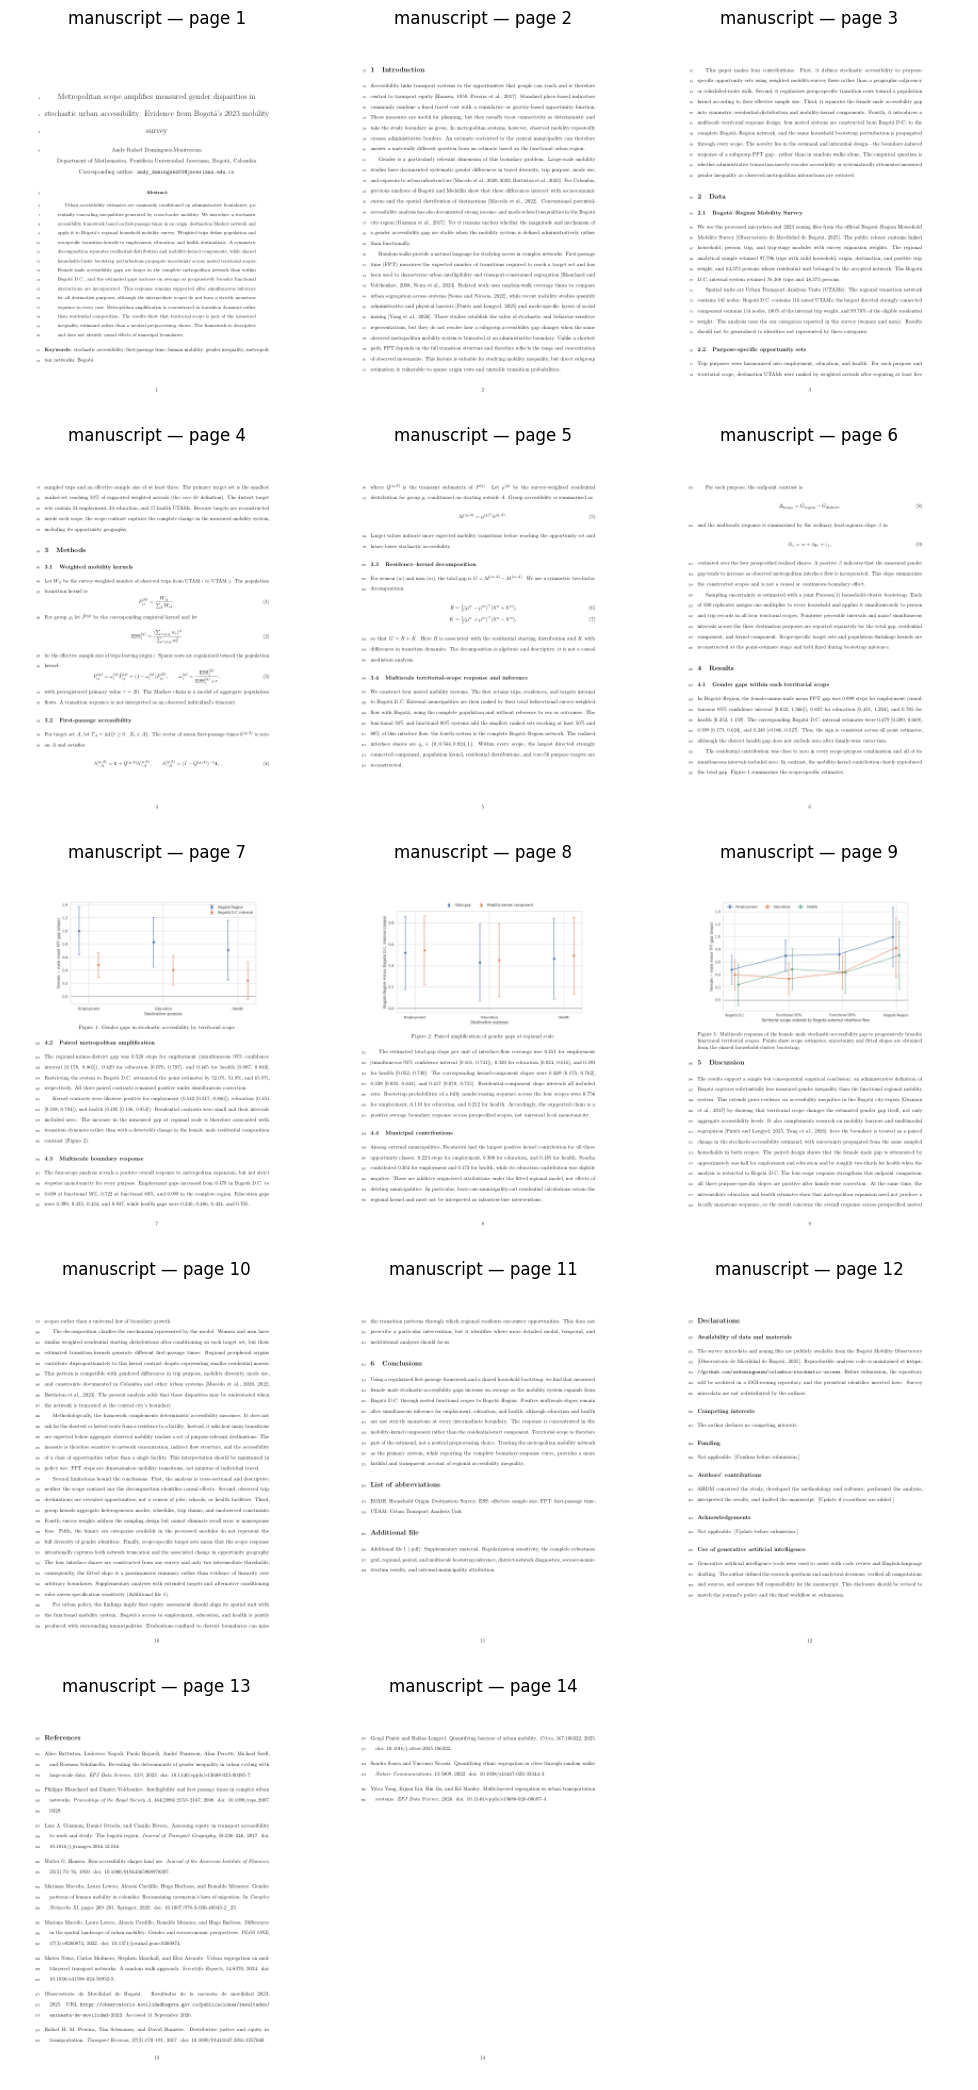

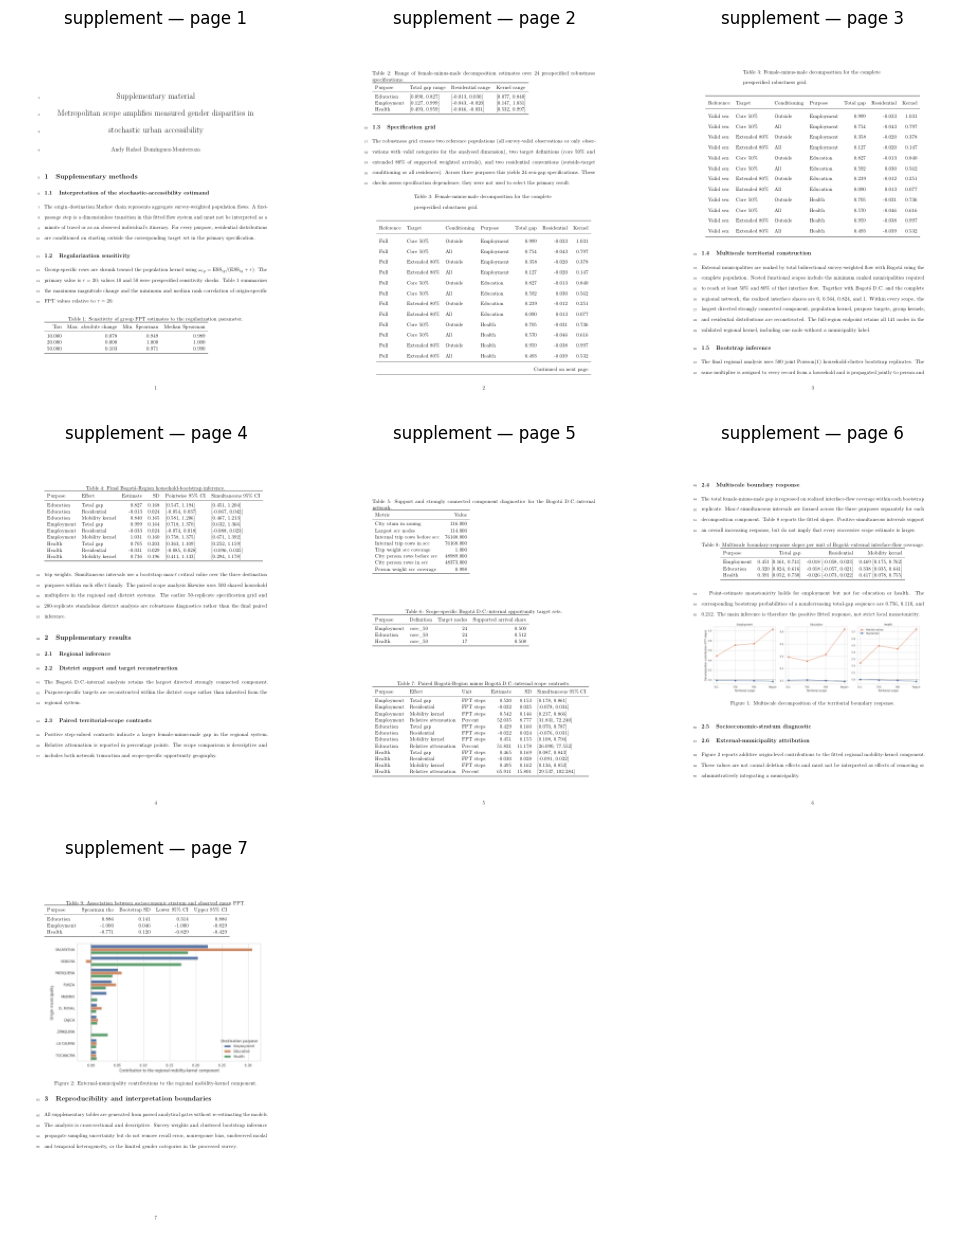

In [12]:
import fitz
import matplotlib.pyplot as plt

for name, result in compiled.items():
    if not result["pdf"].exists():
        continue
    document = fitz.open(result["pdf"])
    images = []
    for page in document:
        pix = page.get_pixmap(matrix=fitz.Matrix(0.45, 0.45), alpha=False)
        images.append(np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n))
    columns = 3
    rows = int(np.ceil(len(images) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(10, 4.2 * rows))
    axes = np.atleast_1d(axes).ravel()
    for index, axis in enumerate(axes):
        axis.axis("off")
        if index < len(images):
            axis.imshow(images[index])
            axis.set_title(f"{name} — page {index + 1}")
    fig.tight_layout()
    preview = OUT / f"{name}_contact_sheet.png"
    fig.savefig(preview, dpi=180, bbox_inches="tight")
    shutil.copy2(preview, persistent / preview.name)
    plt.show()
